## Explainable AI: SHAP and LIME for a decision-support forecast

The forecasting model produces a 120-hour price profile for DK1. The recommendation layer then translates that profile into timing advice: whether a household should consume now to avoid an expensive period or wait for a cheaper window. Explainable AI sits between these two steps. Its purpose is to show which input variables are driving the predicted prices that later become household recommendations.

In this project, XAI has three roles. First, it checks whether the XGBoost models rely on plausible electricity-market drivers such as recent price levels, forecasted wind, solar radiation, temperature, cloud cover, and calendar effects. Second, it supports the dashboard by turning the model from a black box into an inspectable forecast engine. Third, it strengthens the later impact analysis: if simulated load shifting depends on model-based price signals, we should understand what produced those signals before interpreting the estimated system benefit.


In [7]:
import joblib

from src.analysis.explainable_ai import (
    OUTPUT_DIR,
    make_dashboard_shap_summary,
    plot_feature_importance,
    plot_lime_explanations,
    plot_shap_explanations,
)

final_models = joblib.load(OUTPUT_DIR / "final_day_models.joblib")



We start with XGBoost feature importance as a coarse global view. The model is split into five day-specific regressors, so the plot shows whether the short-horizon and long-horizon forecasts depend on similar drivers or whether the dominant predictors change across the 120-hour forecast window.


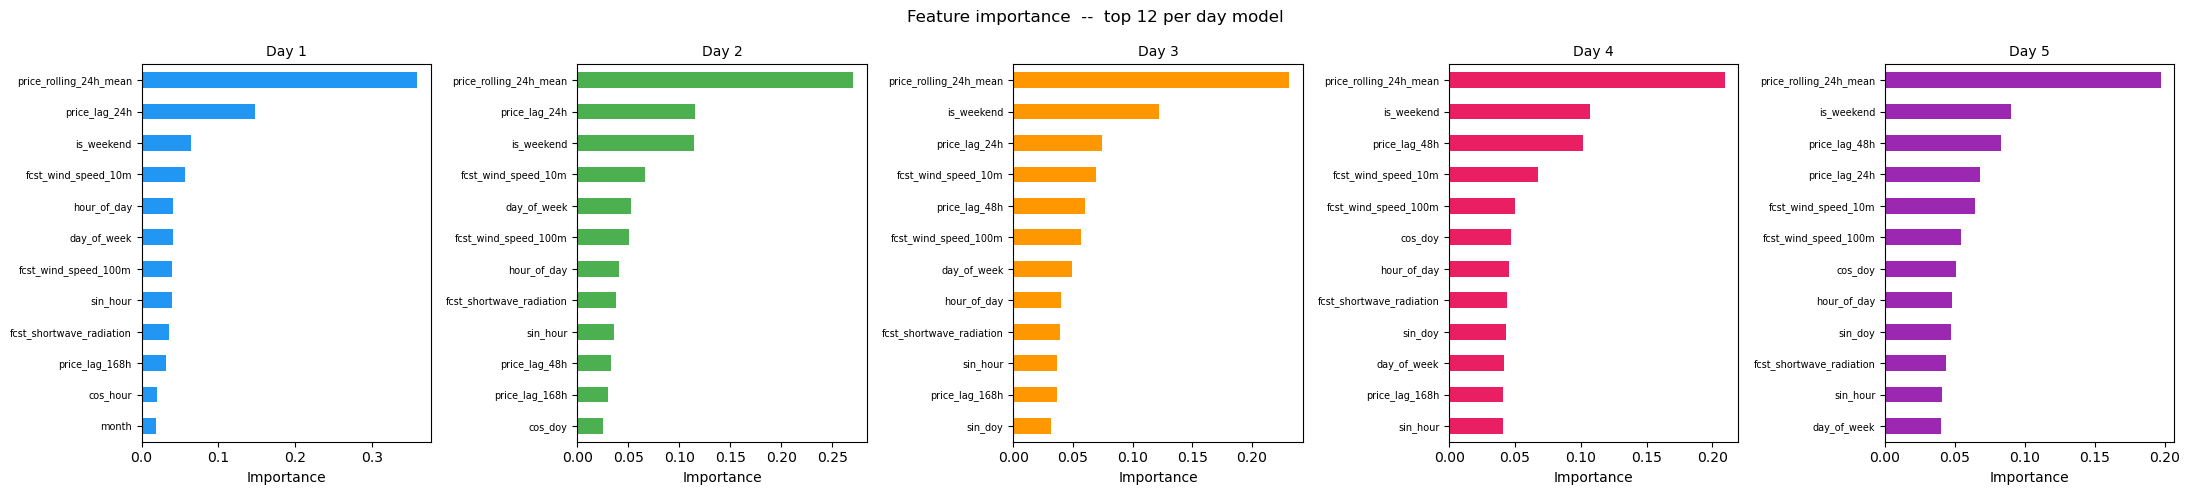

In [8]:
plot_feature_importance(final_models)

Feature importance is useful as an entry point, but it does not show whether a feature pushes the forecast up or down. It can also blur correlated drivers. We therefore use SHAP as the main global explanation method. SHAP decomposes each forecast into additive feature contributions, which is useful when the dashboard recommends a timing decision and we want to understand why a cheap or expensive window appears in the forecast.

In [10]:
plot_shap_explanations(width=1200)

FileNotFoundError: Missing /Users/victorstege/Documents/GitHub/Advanced-Business-Analytics/outputs/model/f. Run `python src/analysis/explainable_ai.py` first.

The SHAP bar plot ranks features by their average absolute contribution to the price forecast, while the beeswarm plot shows the distribution and direction of effects across many sampled forecasts. This distinction matters for recommendations: a feature may be important because high values consistently lift predicted prices, because low values depress prices, or because the effect changes across market regimes.

For the project objective, households do not need to read SHAP plots before using the app. The value is that SHAP gives the project team and dashboard a transparent link between the forecast signal and the market story behind it. A recommendation to wait should be traceable to sensible drivers such as renewable availability, recent price persistence, demand-sensitive weather, or time-of-day effects rather than an arbitrary model artifact.

In [ ]:
dashboard_shap_summary = make_dashboard_shap_summary(top_n=8)
dashboard_shap_summary.style.format(
    {
        "mean_abs_shap_dkk_kwh": "{:.4f}",
        "mean_signed_shap_dkk_kwh": "{:+.4f}",
        "sample_mean_feature_value": "{:.2f}",
    }
)


The table above uses the same Day 1 SHAP export that is loaded by `dashboard.py` from `outputs/model/shap_day1_values.parquet` and `outputs/model/shap_day1_features.parquet`. This allows the Streamlit app to show a lightweight model-insight panel without recomputing SHAP live.

In the dashboard context, this turns XAI into a communication layer. The recommendation text can stay simple and practical, while the app still exposes enough model transparency to answer the natural follow-up question: "why does the model think this period is cheap or expensive?" A future version could use the same SHAP values to generate short explanation snippets next to each recommendation, for example identifying whether a high-price warning is mainly linked to low wind, high recent prices, or peak-hour demand patterns.


In [ ]:
plot_lime_explanations(width=1200)

LIME complements SHAP by focusing on one concrete forecast issue time. It fits a simple local surrogate around the selected forecast instance and shows which features pushed that specific prediction upward or downward. In other words, SHAP answers "what generally drives this model?", while LIME helps answer "why did the model make this recommendation now?"

This local view is important for a consumer recommendation system because the same global model can produce different advice on different days. On one day, the recommended cheap window may be explained by strong wind and low recent prices. On another, a warning to consume earlier may be explained by lower renewable availability, higher lagged prices, and a peak-hour calendar effect.

This also matters for the final impact analysis. The shifting simulation estimates what happens when households react to forecast-based recommendations. XAI does not prove that the behavioral impact will occur, but it makes the mechanism more credible: the simulated shifts are based on price signals that can be inspected and related back to recognizable market drivers. If the impact model shows large benefits while SHAP or LIME reveals that the forecast signal is driven by an implausible artifact, that would be a warning sign before interpreting the resilience contribution.

After retraining the XGBoost models, the XAI artifacts and dashboard SHAP files should be refreshed with `python src/analysis/explainable_ai.py`.
